# Advanced Generative Models Compared (StyleGAN, Stable Diffusion, DALL-E)

## 📚 Learning Objectives

By completing this notebook, you will:
- Describe what distinguishes StyleGAN, Stable Diffusion, and DALL-E architecturally
- Compare the three families on conditioning, quality, control, and access
- Ground the concepts by training a small GAN locally and connecting it to each family
- Know how to reach the real models (open weights vs APIs) for your own experiments

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1 (GAN training) and Unit 3, lesson 04 (diffusion) — the two mechanisms behind all three landmark systems compared here.

**Used later in:** Course 12 (AIAT 126) — Unit 2, when choosing between open weights and a paid API is an architecture decision.

---

This notebook covers practical activities from **Course 10, Unit 5**:
- Experimenting with advanced generative models (StyleGAN, Stable Diffusion, DALL-E)

---

## Introduction

**Advanced generative models** like StyleGAN, Stable Diffusion, and DALL-E represent the
state of the art in image generation.

**Honest scope note:** these models need GPUs, multi-GB weight downloads, or paid APIs — too heavy
for a classroom notebook. So here we (1) compare the three families properly, and (2) train a
small GAN on MNIST *locally* — the same adversarial core StyleGAN scales up — then point you to
the real models for at-home experimentation.

---

## 🌍 Why this lesson exists — Adobe sold the training data, not the model

When Adobe launched **Firefly** in early 2023 it made an unusual claim for a generative image model: it had been trained on Adobe Stock, openly licensed content and public-domain material rather than on a web scrape. Adobe then turned that into a commercial product feature — **contractual IP indemnification** for enterprise customers, covering legal defence and damages from third-party IP claims arising from Firefly outputs.

No row in the table below about "core mechanism" explains that decision. Adobe competed on **provenance and access terms**, because that is what enterprise buyers were actually blocked on. The architecture was table stakes.

**What goes wrong without this:** mechanism differences are what you learn; access, licence and provenance differences are what decide the project. A team that chooses on mechanism alone arrives at the procurement meeting with the right diagram and loses.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

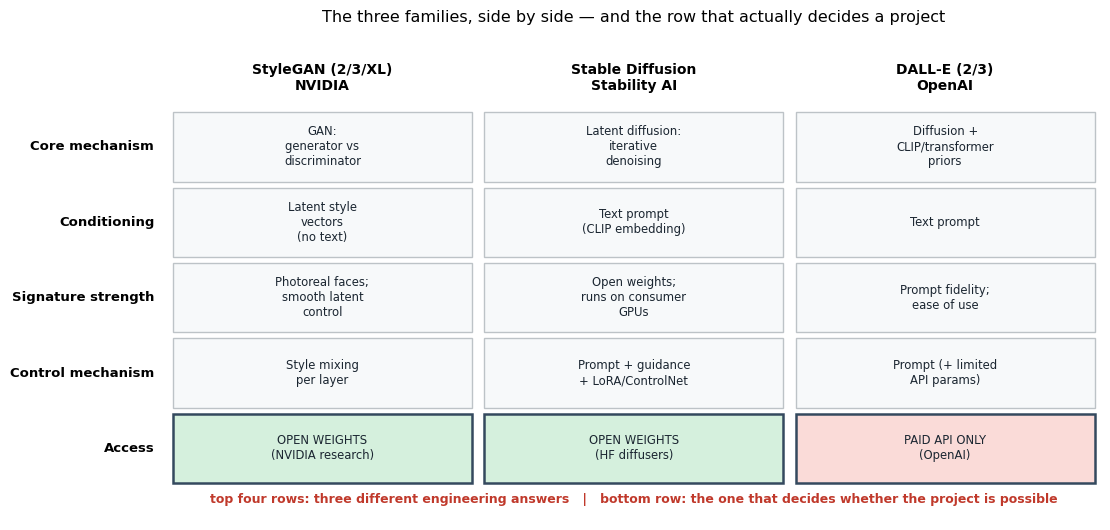

Same information as the table below, one line per family:
  StyleGAN (2/3/XL)    mechanism = GAN: generator vs discriminator        access = OPEN WEIGHTS
  Stable Diffusion     mechanism = Latent diffusion: iterative denoising  access = OPEN WEIGHTS
  DALL-E (2/3)         mechanism = Diffusion + CLIP/transformer priors    access = PAID API ONLY

Adobe Firefly competed on neither column: it sold licensed training data
and contractual IP indemnification. Terms, not mechanism.


In [1]:
# WHAT/WHY: the three families, drawn instead of listed. The lesson's claim is that
# mechanism is NOT what separates these systems in practice — access and provenance are.
# A printed bullet list hides that; a matrix with the access row colour-coded shows it.
# Every cell below is the same content as the markdown table in the next section.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

SYSTEMS  = ["StyleGAN (2/3/XL)\nNVIDIA", "Stable Diffusion\nStability AI", "DALL-E (2/3)\nOpenAI"]
CRITERIA = ["Core mechanism", "Conditioning", "Signature strength", "Control mechanism", "Access"]
CELLS = [
    ["GAN:\ngenerator vs\ndiscriminator", "Latent diffusion:\niterative\ndenoising",   "Diffusion +\nCLIP/transformer\npriors"],
    ["Latent style\nvectors\n(no text)",   "Text prompt\n(CLIP embedding)",             "Text prompt"],
    ["Photoreal faces;\nsmooth latent\ncontrol", "Open weights;\nruns on consumer\nGPUs", "Prompt fidelity;\nease of use"],
    ["Style mixing\nper layer",             "Prompt + guidance\n+ LoRA/ControlNet",      "Prompt (+ limited\nAPI params)"],
    ["OPEN WEIGHTS\n(NVIDIA research)",     "OPEN WEIGHTS\n(HF diffusers)",              "PAID API ONLY\n(OpenAI)"],
]
# Only the last row is colour-coded, because only the last row changes the project plan:
# green = you can download and run it, red = you rent it through someone else's endpoint.
ACCESS_COLOUR = ["#d5f0dd", "#d5f0dd", "#fadbd8"]

fig, ax = plt.subplots(figsize=(11.2, 5.4))
ax.set_xlim(0, 3); ax.set_ylim(0, len(CRITERIA) + 0.9); ax.axis("off")

for col, sysname in enumerate(SYSTEMS):                       # column headers
    ax.text(col + 0.5, len(CRITERIA) + 0.42, sysname, ha="center", va="center",
            fontsize=10, fontweight="bold")
for row, crit in enumerate(CRITERIA):
    y = len(CRITERIA) - 1 - row                               # row 0 drawn at the top
    ax.text(-0.04, y + 0.5, crit, ha="right", va="center", fontsize=9.5, fontweight="bold")
    for col in range(3):
        last = (row == len(CRITERIA) - 1)
        face = ACCESS_COLOUR[col] if last else "#f7f9fa"
        edge = "#34495e" if last else "#bdc3c7"
        ax.add_patch(Rectangle((col + 0.02, y + 0.04), 0.96, 0.92,
                               facecolor=face, edgecolor=edge, lw=1.8 if last else 1.0))
        ax.text(col + 0.5, y + 0.5, CELLS[row][col], ha="center", va="center",
                fontsize=8.4, color="#1b2631")

# the sentence the colour coding is making, placed under the bottom row so it
# stays inside the axes (annotations to the right of x=3 get clipped away)
ax.text(1.5, -0.18, "top four rows: three different engineering answers   |   "
                    "bottom row: the one that decides whether the project is possible",
        ha="center", va="center", fontsize=9, color="#c0392b", fontweight="bold")
ax.set_ylim(-0.45, len(CRITERIA) + 0.9)
ax.set_title("The three families, side by side — and the row that actually decides a project",
             fontsize=11.5, pad=14)
plt.tight_layout(); plt.show()

print("Same information as the table below, one line per family:")
for col, s in enumerate(SYSTEMS):
    print(f"  {s.splitlines()[0]:<20} mechanism = {CELLS[0][col].replace(chr(10), ' '):<38}"
          f" access = {CELLS[4][col].splitlines()[0]}")
print("\nAdobe Firefly competed on neither column: it sold licensed training data")
print("and contractual IP indemnification. Terms, not mechanism.")

**Read the figure.** Five rows, three columns, and only the bottom row is coloured. Read the top
four rows across and you get three genuinely different engineering answers — an adversarial game, a
denoising process, a denoiser steered by a text prior — with different conditioning, different
strengths, different control knobs. Those rows are the ones this course teaches you.

Now read the bottom row. Two green cells and one red one, and the difference between them is not
technical: green means the weights are yours to download and run on hardware you control, red means
every image is a call to somebody else's endpoint under somebody else's terms. That single row
decides whether a project can run offline, what it costs per image, whether it survives a price
change, and whether your client's data leaves the building.

The four rows above it are the interesting ones. **The row underneath is the one that cancels
projects** — and Adobe built Firefly's entire market position on a sixth row this table does not
even have: where the training data came from, and who pays if someone sues.

## The Three Families, Side by Side

| | **StyleGAN (2/3/XL)** | **Stable Diffusion** | **DALL-E (2/3)** |
|---|---|---|---|
| Core mechanism | GAN — generator vs discriminator | Latent diffusion — iterative denoising | Diffusion + CLIP/transformer priors |
| Conditioning | Latent style vectors (no text) | Text prompt (CLIP embedding) | Text prompt |
| Signature strength | Photoreal faces; smooth latent control | Open weights; runs on consumer GPUs | Prompt fidelity; ease of use |
| Control mechanism | Style mixing per layer | Prompt + guidance scale + LoRA/ControlNet | Prompt (+ limited API params) |
| Access | Open weights (NVIDIA research) | Open weights (Hugging Face `diffusers`) | Paid API only (OpenAI) |
| Relation to today's demo | Same adversarial loss, scaled ~10,000x | Different mechanism — see Unit 3's DDPM demo | Different mechanism + text encoder |

**Try the real ones at home:**

- *Stable Diffusion* (open, needs a GPU): the `diffusers` library —
  `StableDiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2-1")`
- *StyleGAN3* pretrained faces: NVIDIA's official GitHub release
- *DALL-E 3*: via the OpenAI Images API (paid)

Below, the hands-on part: the adversarial core of the GAN family, small enough to train here.

## 🌍 Hands-On — the GAN Core That StyleGAN Scales Up

**Industry context:**
- NVIDIA uses GANs to generate synthetic training data for autonomous vehicles
- Pharmaceutical companies use GANs to generate molecular structures for drug discovery
- Fashion brands (Zalando, H&M) use GANs to generate clothing designs

We train a **small fully-connected GAN** (linear layers only — StyleGAN's generator adds
convolutions, progressive resolution, and per-layer style injection on top of this exact
adversarial recipe) to generate handwritten digits from pure noise.

Epoch 1/10 — D loss: 0.726  G loss: 2.918


Epoch 2/10 — D loss: 0.615  G loss: 1.806


Epoch 3/10 — D loss: 0.517  G loss: 2.125


Epoch 4/10 — D loss: 0.803  G loss: 1.371


Epoch 5/10 — D loss: 0.646  G loss: 1.535


Epoch 6/10 — D loss: 0.466  G loss: 2.699


Epoch 7/10 — D loss: 0.628  G loss: 1.982


Epoch 8/10 — D loss: 0.508  G loss: 2.673


Epoch 9/10 — D loss: 0.866  G loss: 2.783


Epoch 10/10 — D loss: 0.771  G loss: 1.519


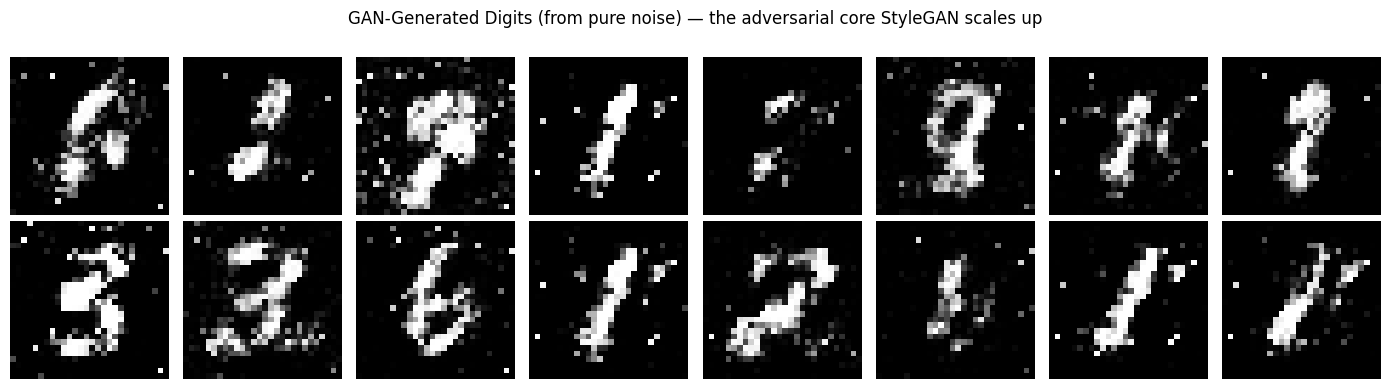

In [2]:
# Train a small fully-connected GAN on MNIST — the adversarial core of the GAN family.
# WHY: generator vs discriminator with BCE loss is exactly what StyleGAN scales up;
# training it yourself makes the comparison table above concrete.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise → image ───────────────────────────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: image → real/fake ─────────────────────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
bce   = nn.BCELoss()

# ── A FIXED batch of latent vectors, photographed after every epoch ───────
# WHY: to SEE a generator improve you must hold z constant. Then anything that
# changes in the picture is the generator changing, not a different random draw.
z_fixed = torch.randn(8, LATENT_DIM)
snapshots = []

d_losses, g_losses = [], []
for epoch in range(10):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── Train Discriminator ─────────────────────────────────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs,1)) + bce(D(fake), torch.zeros(bs,1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── Train Generator ─────────────────────────────────────────────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs,1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    with torch.no_grad():                     # same 8 latents, one frame per epoch
        snapshots.append(G(z_fixed).view(-1, 28, 28).numpy())
    print(f"Epoch {epoch+1}/10 — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Show generated images ──────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray'); ax.axis('off')
plt.suptitle("GAN-Generated Digits (from pure noise) — the adversarial core StyleGAN scales up")
plt.tight_layout(); plt.show()

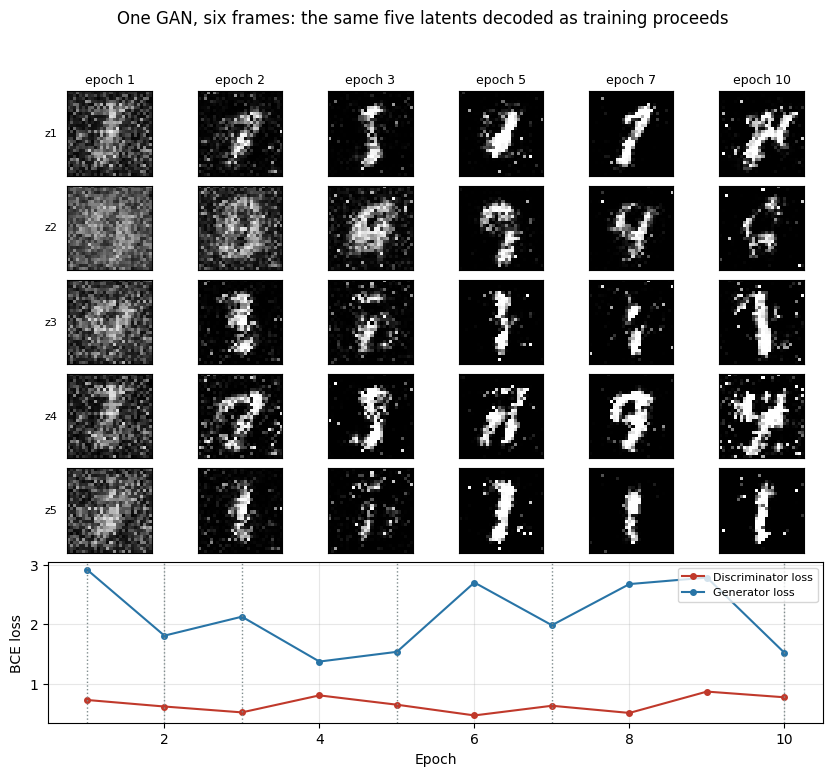

 epoch |  D loss |  G loss |  mean |pixel| of the 8 fixed samples
     1 |   0.726 |   2.918 |                                0.505
     2 |   0.615 |   1.806 |                                0.789
     3 |   0.517 |   2.125 |                                0.887
     5 |   0.646 |   1.535 |                                0.938
     7 |   0.628 |   1.982 |                                0.944
    10 |   0.771 |   1.519 |                                0.926


In [3]:
# Frame grid: the SAME five latent vectors, decoded after each of six epochs, with the
# two losses that produced them underneath. WHY: a GAN is a process, and the single grid
# of finished digits above hides it. A static storyboard always renders — no animation
# machinery, no extra training cost (each frame is one forward pass of 8 vectors).
import matplotlib.pyplot as plt

FRAMES = [0, 1, 2, 4, 6, 9]                  # list indices -> epochs 1, 2, 3, 5, 7, 10
N_ROWS = 5                                   # how many of the 8 fixed latents to show

fig = plt.figure(figsize=(10, 8.2))
gs = fig.add_gridspec(N_ROWS + 1, len(FRAMES),
                      height_ratios=[1] * N_ROWS + [1.9], hspace=0.10, wspace=0.06)

for col, idx in enumerate(FRAMES):           # one column per photographed epoch
    for row in range(N_ROWS):                # one row per fixed latent vector
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(snapshots[idx][row], cmap="gray", vmin=-1, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f"epoch {idx + 1}", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"z{row + 1}", fontsize=8, rotation=0, labelpad=12, va="center")

axl = fig.add_subplot(gs[N_ROWS, :])         # the losses, aligned under the frames
epochs = range(1, len(d_losses) + 1)
axl.plot(epochs, d_losses, "o-", color="#c0392b", ms=4, label="Discriminator loss")
axl.plot(epochs, g_losses, "o-", color="#2874a6", ms=4, label="Generator loss")
for idx in FRAMES:
    axl.axvline(idx + 1, ls=":", color="#7f8c8d", lw=1)
axl.set_xlabel("Epoch"); axl.set_ylabel("BCE loss"); axl.set_xlim(0.5, len(d_losses) + 0.5)
axl.legend(fontsize=8); axl.grid(alpha=0.3)
fig.suptitle("One GAN, six frames: the same five latents decoded as training proceeds", fontsize=12)
plt.show()

# ── The same storyboard as a printed step table ───────────────────────────
print(f"{'epoch':>6} | {'D loss':>7} | {'G loss':>7} | {'mean |pixel| of the 8 fixed samples':>36}")
for idx in FRAMES:
    print(f"{idx + 1:>6} | {d_losses[idx]:7.3f} | {g_losses[idx]:7.3f} | "
          f"{abs(snapshots[idx]).mean():36.3f}")


**Read the storyboard.**

*Top* — six frames of a single training run. Each **row is one fixed latent vector** and each
**column is an epoch**, so a row is that vector's whole journey through training. Read it left to
right: at epoch 1 there is grey noise with a faint bright smudge and no stroke anywhere; by epoch
2–3 a bright stroke has separated from a darkening background; by epochs 7–10 several rows hold
pen-stroke shapes with digit-like topology, while others are still re-forming into something else.
The printed table gives the background effect a number — mean |pixel| climbs from **0.51 to ~0.93**
as the generator's `tanh` output saturates towards black and white. Ten epochs of a
fully-connected GAN buys you "stroke-like", not "clean digit"; that gap is what convolutions,
progressive growing and 10,000x the compute buy StyleGAN.

*Bottom* — the same run's two losses, with dotted lines on the six photographed epochs. They do
**not** descend. The discriminator sits near 0.5–0.9 while the generator swings between roughly
1.4 and 2.9, because each network's loss depends on how good its opponent currently is. This is
the practical consequence of the adversarial setup: **in a GAN the loss curve is not the progress
report — the samples are.** If you take one habit from this notebook into your own GAN work, it is
to keep a fixed batch of latents and photograph it every epoch, exactly as the grid above does.

## 💬 Discuss

1. Adobe built Firefly on licensed content and sold indemnification with it. Rank the six rows of the comparison table by how much each would matter to a Saudi bank's marketing team. Does "core mechanism" make your top three? Defend the ranking.
2. Our GAN and Unit 3's diffusion demo both produce rough digits. What can you say — from evidence generated *in this course* — about which family is better? What would you have to run before you could say more?
3. StyleGAN has open weights but no text control; Stable Diffusion has both. Name a real project where "no text control" is the right answer, and say what makes it right.


## ⚠️ Where this breaks

**Nothing here runs the three large systems**, so every quality claim in the table is literature, not measurement. Present it that way or you are passing off a reading list as a benchmark.

**The table ages fast, and the "access" row fastest.** Licences change, APIs open and close, and by 2026 the mechanism column understates how far the field moved past both GANs and pixel-space diffusion. Re-derive it from current model cards before you brief anyone.

**Training the adversarial core teaches the mechanism, not the engineering.** At production scale the hard parts are data curation, distributed training, safety filtering and inference cost — none of which appear in a 10-epoch MNIST run, and all of which are where projects fail.

**"Open weights" does not mean "safe to use commercially".** Adobe's whole differentiator is that the two questions are separate: what you may do with the model (licence) and what the model may have absorbed (provenance). Check both, in writing.


## 📝 Summary

In this notebook, you:

- Compared **StyleGAN, Stable Diffusion, and DALL-E** across mechanism, conditioning, control,
  and access — and saw why only one of the three (Stable Diffusion) has open weights
- Trained a small **GAN locally** and connected its adversarial recipe to what StyleGAN scales up
- Collected concrete entry points (`diffusers`, StyleGAN3 releases, OpenAI API) for experimenting
  with the real models on your own hardware

**Honest scope note:** we did not run the three large models here — they require GPUs or paid
APIs; what you ran is the small-scale core of the GAN family plus Unit 3's diffusion demo.

## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434)
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)

**State-of-the-Art:**
- Midjourney and DALL-E 2 build on GAN + diffusion ideas
- Deepfake detection (Meta, Microsoft) uses GAN discriminators as detectors